# Chapter 13.5 The TensorFlow Datasets Project

In [1]:
import tensorflow_datasets as tfds

dataset = tfds.load(name="mnist")
dataset.keys()

2022-10-22 09:16:52.760458: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-22 09:16:52.830599: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-22 09:16:52.831033: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-22 09:16:52.833382: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

dict_keys(['test', 'train'])

In [2]:
mnist_train, mnist_test = dataset["train"], dataset["test"]
mnist_train

<PrefetchDataset element_spec={'image': TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>

2022-10-22 09:16:54.893597: W tensorflow/core/kernels/data/cache_dataset_ops.cc:768] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


NameError: name 'image' is not defined

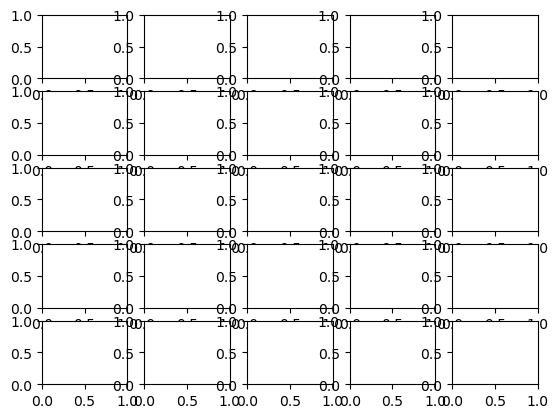

In [ ]:
import matplotlib.pyplot as plt

n_rows = 5
n_cols = 5
fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, squeeze=False)

mnist_train = mnist_train.shuffle(10_000).batch(32).prefetch(1)
for i_item, (ax, item) in enumerate(zip(axs.ravel(), mnist_train)):
    if i_item >= 25:
        break

    image = item["image"]
    labels = item["label"]
    ax.imshow(image)